# Classic Inpainting

In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import cv2

import torch
from torch.utils.data import Dataset, DataLoader

Train images: 18400
Val images:   2800
Test images:  2800


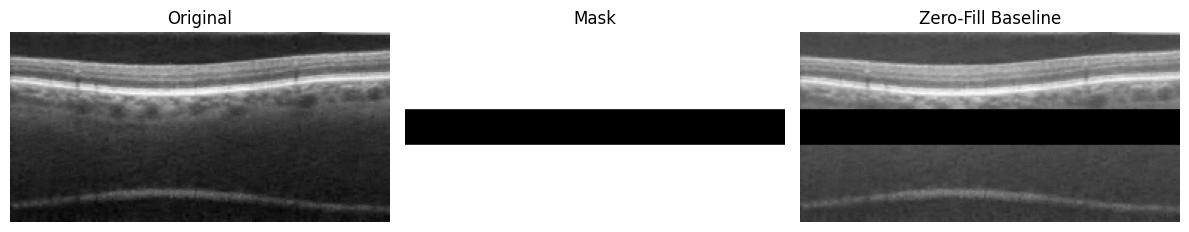

In [3]:
# Dataset paths

DATA_DIR = Path("../data/raw/retinal-oct-c8/RetinalOCT_Dataset/RetinalOCT_Dataset")

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

class_names = sorted(
    [p.name for p in TRAIN_DIR.iterdir() if p.is_dir()]
)

train_paths = sorted(list(TRAIN_DIR.glob("*/*.jpg")))
val_paths = sorted(list(VAL_DIR.glob("*/*.jpg")))
test_paths = sorted(list(TEST_DIR.glob("*/*.jpg")))

print(f"Train images: {len(train_paths)}")
print(f"Val images:   {len(val_paths)}")
print(f"Test images:  {len(test_paths)}")


# Preprocessing

TARGET_SIZE = (256, 128)  # width, height

def preprocess_image(path, target_size=TARGET_SIZE):
    
    img = Image.open(path).convert("L")
    
    img = img.resize(
        target_size,
        resample=Image.BILINEAR
    )
    
    arr = np.array(img).astype(np.float32)
    
    arr = arr / 255.0
    
    return arr


# Mask generators

def center_mask(shape, mask_size=(64, 64)):
    
    h, w = shape
    
    mask = np.ones((h, w), dtype=np.float32)
    
    mh, mw = mask_size
    
    top = (h - mh) // 2
    left = (w - mw) // 2
    
    mask[top:top+mh, left:left+mw] = 0.0
    
    return mask


def horizontal_stripe_mask(shape, stripe_height=24):
    
    h, w = shape
    
    mask = np.ones((h, w), dtype=np.float32)
    
    center = h // 2
    
    top = center - stripe_height // 2
    
    mask[top:top+stripe_height, :] = 0.0
    
    return mask


def random_square_mask(shape, square_size=48):
    
    h, w = shape
    
    mask = np.ones((h, w), dtype=np.float32)
    
    top = np.random.randint(0, h - square_size)
    left = np.random.randint(0, w - square_size)
    
    mask[top:top+square_size, left:left+square_size] = 0.0
    
    return mask


# Dataset object

class OCTInpaintingDataset(Dataset):
    
    def __init__(
        self,
        image_paths,
        preprocess_fn,
        mask_fn
    ):
        self.image_paths = image_paths
        self.preprocess_fn = preprocess_fn
        self.mask_fn = mask_fn
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        
        path = self.image_paths[idx]
        
        # Preprocess image
        img = self.preprocess_fn(path)
        
        # Generate mask
        mask = self.mask_fn(img.shape)
        
        # Corrupt image
        masked_img = img * mask
        
        # Convert to tensors
        img = torch.tensor(img).unsqueeze(0).float()
        mask = torch.tensor(mask).unsqueeze(0).float()
        masked_img = torch.tensor(masked_img).unsqueeze(0).float()
        
        return {
            "image": img,
            "mask": mask,
            "masked_image": masked_img
        }


# Create dataset

stripe_dataset = OCTInpaintingDataset(
    image_paths=train_paths,
    preprocess_fn=preprocess_image,
    mask_fn=horizontal_stripe_mask
)

sample = stripe_dataset[0]

original = sample["image"].squeeze().numpy()
masked = sample["masked_image"].squeeze().numpy()
mask = sample["mask"].squeeze().numpy()


# Zero-fill baseline visualization

fig, axes = plt.subplots(1, 3, figsize=(12,4))

axes[0].imshow(original, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Mask")
axes[1].axis("off")

axes[2].imshow(masked, cmap="gray")
axes[2].set_title("Zero-Fill Baseline")
axes[2].axis("off")

plt.tight_layout()
plt.show()

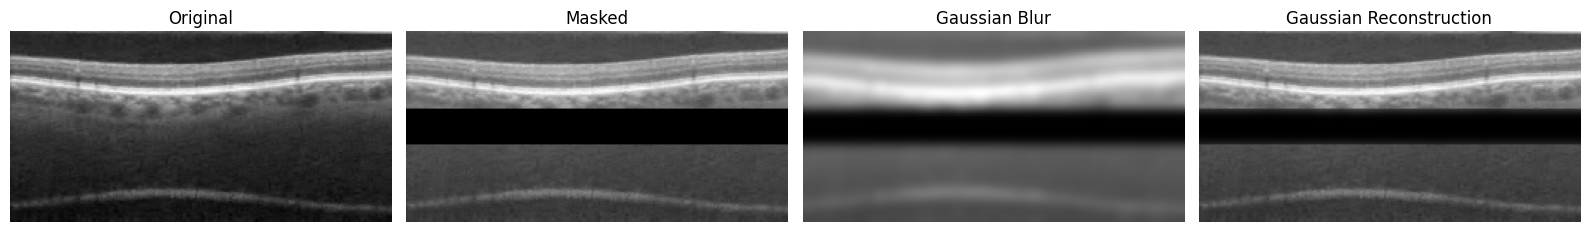

In [4]:
# Gaussian blur reconstruction baseline

blurred = cv2.GaussianBlur(
    masked,
    ksize=(21, 21),
    sigmaX=0
)

# Only fill missing regions
gaussian_recon = masked.copy()

gaussian_recon[mask == 0] = blurred[mask == 0]

# Visualization
fig, axes = plt.subplots(1, 4, figsize=(16,4))

axes[0].imshow(original, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(masked, cmap="gray")
axes[1].set_title("Masked")
axes[1].axis("off")

axes[2].imshow(blurred, cmap="gray")
axes[2].set_title("Gaussian Blur")
axes[2].axis("off")

axes[3].imshow(gaussian_recon, cmap="gray")
axes[3].set_title("Gaussian Reconstruction")
axes[3].axis("off")

plt.tight_layout()
plt.show()

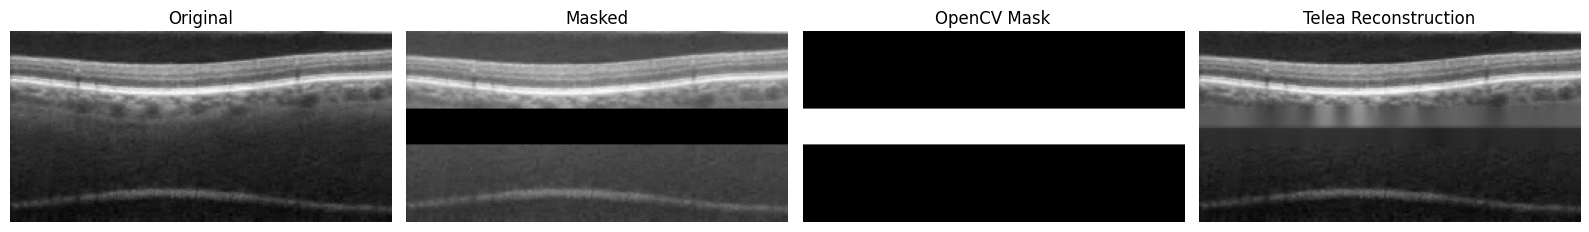

In [5]:
# OpenCV inpainting baseline

# OpenCV expects uint8
masked_uint8 = (masked * 255).astype(np.uint8)

# Inpainting mask:
# OpenCV expects:
# 255 = region to fill
# 0 = keep
opencv_mask = ((1 - mask) * 255).astype(np.uint8)

# Telea inpainting
telea_recon = cv2.inpaint(
    masked_uint8,
    opencv_mask,
    inpaintRadius=3,
    flags=cv2.INPAINT_TELEA
)

# Convert back to [0,1]
telea_recon = telea_recon.astype(np.float32) / 255.0

# Visualization
fig, axes = plt.subplots(1, 4, figsize=(16,4))

axes[0].imshow(original, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(masked, cmap="gray")
axes[1].set_title("Masked")
axes[1].axis("off")

axes[2].imshow(opencv_mask, cmap="gray")
axes[2].set_title("OpenCV Mask")
axes[2].axis("off")

axes[3].imshow(telea_recon, cmap="gray")
axes[3].set_title("Telea Reconstruction")
axes[3].axis("off")

plt.tight_layout()
plt.show()

In [6]:
# Reconstruction metrics
def masked_mse(original, reconstruction, mask):
    
    missing_region = (mask == 0)
    
    mse = np.mean(
        (original[missing_region] - reconstruction[missing_region]) ** 2
    )
    
    return mse


def masked_mae(original, reconstruction, mask):
    
    missing_region = (mask == 0)
    
    mae = np.mean(
        np.abs(original[missing_region] - reconstruction[missing_region])
    )
    
    return mae


def psnr(original, reconstruction):
    
    mse = np.mean((original - reconstruction) ** 2)
    
    if mse == 0:
        return float("inf")
    
    return 20 * np.log10(1.0 / np.sqrt(mse))

In [7]:
# Compare baseline metrics
zero_fill_mse = masked_mse(original, masked, mask)
gaussian_mse = masked_mse(original, gaussian_recon, mask)
telea_mse = masked_mse(original, telea_recon, mask)

print("Masked-region MSE")
print("------------------")
print(f"Zero-fill: {zero_fill_mse:.6f}")
print(f"Gaussian : {gaussian_mse:.6f}")
print(f"Telea    : {telea_mse:.6f}")

print()

print("PSNR")
print("----")
print(f"Gaussian : {psnr(original, gaussian_recon):.2f}")
print(f"Telea    : {psnr(original, telea_recon):.2f}")

Masked-region MSE
------------------
Zero-fill: 0.119729
Gaussian : 0.094477
Telea    : 0.002804

PSNR
----
Gaussian : 17.52
Telea    : 32.79


In [8]:
def evaluate_baselines(dataset, n_samples=100):
    rows = []
    
    for i in range(n_samples):
        sample = dataset[i]
        
        original = sample["image"].squeeze().numpy()
        masked = sample["masked_image"].squeeze().numpy()
        mask = sample["mask"].squeeze().numpy()
        
        blurred = cv2.GaussianBlur(masked, ksize=(21, 21), sigmaX=0)
        gaussian_recon = masked.copy()
        gaussian_recon[mask == 0] = blurred[mask == 0]
        
        masked_uint8 = (masked * 255).astype(np.uint8)
        opencv_mask = ((1 - mask) * 255).astype(np.uint8)
        telea_recon = cv2.inpaint(
            masked_uint8,
            opencv_mask,
            inpaintRadius=3,
            flags=cv2.INPAINT_TELEA
        ).astype(np.float32) / 255.0
        
        rows.append({
            "zero_fill_mse": masked_mse(original, masked, mask),
            "gaussian_mse": masked_mse(original, gaussian_recon, mask),
            "telea_mse": masked_mse(original, telea_recon, mask),
            "gaussian_psnr": psnr(original, gaussian_recon),
            "telea_psnr": psnr(original, telea_recon),
        })
    
    return pd.DataFrame(rows)

In [9]:
import pandas as pd
baseline_results = evaluate_baselines(stripe_dataset, n_samples=100)

baseline_results.describe()

,zero_fill_mse,gaussian_mse,telea_mse,gaussian_psnr,telea_psnr
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,0.151814,0.121965,0.010596,16.676598,29.470547
std,0.050286,0.042582,0.008998,1.566527,5.401708
min,0.068891,0.054773,0.000464,12.932520,21.824245
25%,0.115603,0.091784,0.002254,15.608406,25.101393
50%,0.149524,0.120509,0.009869,16.460094,27.327806
75%,0.182551,0.146609,0.016476,17.642323,33.761470
max,0.323413,0.271486,0.035041,19.884342,40.605942
